In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv("../data/risk_index.csv")

print("Datos cargados OK")
print(f"Años disponibles: {df['year'].min()} - {df['year'].max()}")

Datos cargados OK
Años disponibles: 2005 - 2023


In [2]:
# Escenarios basados en reformas de Milei y proyecciones del FMI
scenarios = {
    "Optimistisch": {
        "inflation":    [50.0, 25.0, 12.0, 8.0],
        "gdp_growth":   [3.0,  4.5,  5.0,  5.5],
        "unemployment": [6.5,  6.0,  5.5,  5.0],
        "debt_to_gdp":  [85.0, 80.0, 75.0, 70.0],
        "fdi_inflow":   [2.5,  3.5,  4.5,  5.5],
        "description":  "Reformas exitosas, inflación controlada, acceso a mercados"
    },
    "Basisszenario": {
        "inflation":    [120.0, 60.0, 35.0, 25.0],
        "gdp_growth":   [-2.0,  2.0,  3.0,  3.5],
        "unemployment": [8.0,   7.5,  7.0,  6.5],
        "debt_to_gdp":  [90.0,  88.0, 85.0, 82.0],
        "fdi_inflow":   [1.5,   2.0,  2.5,  3.0],
        "description":  "Reformas parciales, estabilización gradual"
    },
    "Pessimistisch": {
        "inflation":    [200.0, 180.0, 150.0, 120.0],
        "gdp_growth":   [-5.0,  -3.0,  -1.0,   1.0],
        "unemployment": [12.0,  14.0,  13.0,  11.0],
        "debt_to_gdp":  [100.0, 110.0, 115.0, 120.0],
        "fdi_inflow":   [0.5,   0.3,   0.5,   0.8],
        "description":  "Colapso político, default, crisis social"
    }
}

YEARS_FUTURE = [2024, 2025, 2026, 2027]

print("Escenarios definidos OK")
for name, data in scenarios.items():
    print(f"  {name}: {data['description']}")

Escenarios definidos OK
  Optimistisch: Reformas exitosas, inflación controlada, acceso a mercados
  Basisszenario: Reformas parciales, estabilización gradual
  Pessimistisch: Colapso político, default, crisis social


In [3]:
# Necesitamos los min/max históricos para normalizar igual que antes
hist_ar = df[df["country"] == "Argentina"].copy()

# Rangos históricos globales (mismos que usamos en notebook 2)
ranges = {}
for col in ["inflation", "gdp_growth", "unemployment", "debt_to_gdp", "fdi_inflow"]:
    ranges[col] = {"min": df[col].min(), "max": df[col].max()}

WEIGHTS = {
    "r_inflation":    0.35,
    "r_debt":         0.20,
    "r_gdp":          0.20,
    "r_unemployment": 0.15,
    "r_fdi":          0.10,
}

def calcular_riesgo(inflation, gdp, unemployment, debt, fdi):
    def norm(val, col):
        mn, mx = ranges[col]["min"], ranges[col]["max"]
        return (val - mn) / (mx - mn) * 100

    def norm_inv(val, col):
        return 100 - norm(val, col)

    r = (
        norm(inflation,    "inflation")    * WEIGHTS["r_inflation"] +
        norm(debt,         "debt_to_gdp")  * WEIGHTS["r_debt"] +
        norm_inv(gdp,      "gdp_growth")   * WEIGHTS["r_gdp"] +
        norm(unemployment, "unemployment") * WEIGHTS["r_unemployment"] +
        norm_inv(fdi,      "fdi_inflow")   * WEIGHTS["r_fdi"]
    )
    return round(r, 2)

# Calcular índice para cada escenario
scenario_results = {}
for name, data in scenarios.items():
    indices = []
    for i, year in enumerate(YEARS_FUTURE):
        idx = calcular_riesgo(
            data["inflation"][i],
            data["gdp_growth"][i],
            data["unemployment"][i],
            data["debt_to_gdp"][i],
            data["fdi_inflow"][i]
        )
        indices.append(idx)
    scenario_results[name] = indices

print("Índices por escenario 2024-2027:")
for name, indices in scenario_results.items():
    print(f"  {name}: {indices}")

Índices por escenario 2024-2027:
  Optimistisch: [np.float64(38.74), np.float64(26.71), np.float64(18.81), np.float64(13.27)]
  Basisszenario: [np.float64(67.4), np.float64(45.46), np.float64(35.49), np.float64(29.95)]
  Pessimistisch: [np.float64(100.99), np.float64(98.69), np.float64(87.82), np.float64(75.34)]


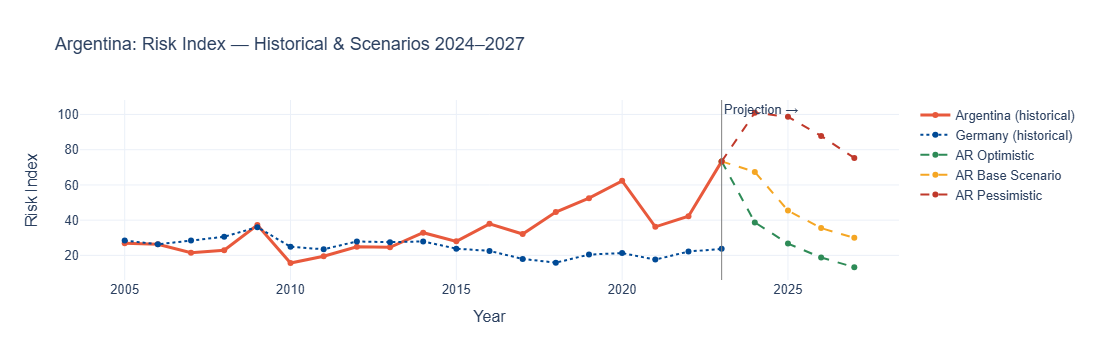

In [9]:
fig = go.Figure()

# Historical Argentina
fig.add_trace(go.Scatter(
    x=hist["year"],
    y=hist["risk_index"],
    name="Argentina (historical)",
    line=dict(color="#E8593C", width=3),
    mode="lines+markers"
))

# Historical Germany
fig.add_trace(go.Scatter(
    x=hist_de["year"],
    y=hist_de["risk_index"],
    name="Germany (historical)",
    line=dict(color="#004A96", width=2, dash="dot"),
    mode="lines+markers"
))

# Future scenarios
colors = {
    "Optimistisch":  "#2E8B57",
    "Basisszenario": "#F5A623",
    "Pessimistisch": "#C0392B"
}

labels = {
    "Optimistisch":  "AR Optimistic",
    "Basisszenario": "AR Base Scenario",
    "Pessimistisch": "AR Pessimistic"
}

for name, indices in scenario_results.items():
    x_vals = [2023] + YEARS_FUTURE
    y_vals = [hist["risk_index"].iloc[-1]] + indices

    fig.add_trace(go.Scatter(
        x=x_vals,
        y=y_vals,
        name=labels[name],
        line=dict(color=colors[name], width=2, dash="dash"),
        mode="lines+markers"
    ))

fig.add_vline(
    x=2023,
    line_dash="solid",
    line_color="gray",
    line_width=1,
    annotation_text="Projection →",
    annotation_position="top right"
)

fig.update_layout(
    title="Argentina: Risk Index — Historical & Scenarios 2024–2027",
    xaxis_title="Year",
    yaxis_title="Risk Index",
    template="plotly_white",
    font=dict(family="Arial", size=13),
    hovermode="x unified",
    legend=dict(orientation="v", x=1.02, y=1)
)

fig.show()

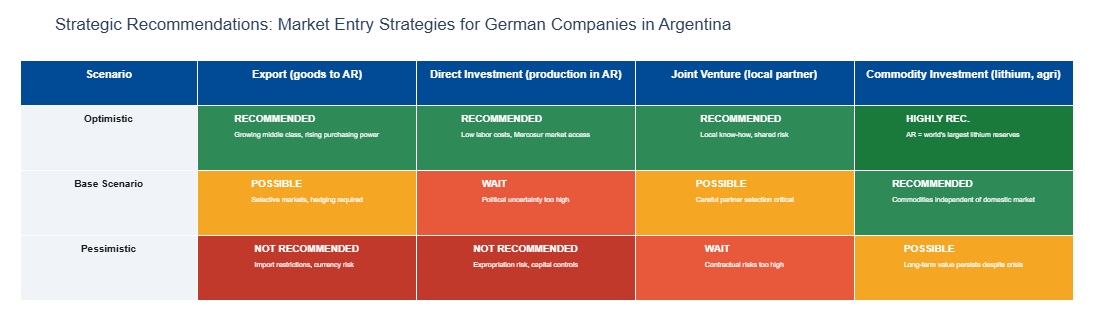

In [11]:
recomendaciones = {
    "Export\n(goods to AR)": {
        "Optimistic":    {"rating": "RECOMMENDED",     "note": "Growing middle class, rising purchasing power"},
        "Base Scenario": {"rating": "POSSIBLE",        "note": "Selective markets, hedging required"},
        "Pessimistic":   {"rating": "NOT RECOMMENDED", "note": "Import restrictions, currency risk"}
    },
    "Direct Investment\n(production in AR)": {
        "Optimistic":    {"rating": "RECOMMENDED",     "note": "Low labor costs, Mercosur market access"},
        "Base Scenario": {"rating": "WAIT",            "note": "Political uncertainty too high"},
        "Pessimistic":   {"rating": "NOT RECOMMENDED", "note": "Expropriation risk, capital controls"}
    },
    "Joint Venture\n(local partner)": {
        "Optimistic":    {"rating": "RECOMMENDED",     "note": "Local know-how, shared risk"},
        "Base Scenario": {"rating": "POSSIBLE",        "note": "Careful partner selection critical"},
        "Pessimistic":   {"rating": "WAIT",            "note": "Contractual risks too high"}
    },
    "Commodity Investment\n(lithium, agri)": {
        "Optimistic":    {"rating": "HIGHLY REC.",     "note": "AR = world's largest lithium reserves"},
        "Base Scenario": {"rating": "RECOMMENDED",     "note": "Commodities independent of domestic market"},
        "Pessimistic":   {"rating": "POSSIBLE",        "note": "Long-term value persists despite crisis"}
    }
}

color_map = {
    "HIGHLY REC.":      "#1a7a3c",
    "RECOMMENDED":      "#2E8B57",
    "POSSIBLE":         "#F5A623",
    "WAIT":             "#E8593C",
    "NOT RECOMMENDED":  "#C0392B"
}

escenarios = ["Optimistic", "Base Scenario", "Pessimistic"]
estrategias = list(recomendaciones.keys())

# Filas = escenarios, Columnas = estrategias
header_values = ["<b>Scenario</b>"] + [f"<b>{e.replace(chr(10), ' ')}</b>" for e in estrategias]

row_labels = []
cell_texts = [[] for _ in estrategias]
cell_colors = [[] for _ in estrategias]

for escenario in escenarios:
    row_labels.append(f"<b>{escenario}</b>")
    for i, estrategia in enumerate(estrategias):
        rec = recomendaciones[estrategia][escenario]
        cell_texts[i].append(f"<b>{rec['rating']}</b><br><sub>{rec['note']}</sub>")
        cell_colors[i].append(color_map[rec["rating"]])

fig2 = go.Figure(data=[go.Table(
    columnwidth=[130, 160, 160, 160, 160],
    header=dict(
        values=header_values,
        fill_color="#004A96",
        font=dict(color="white", size=11, family="Arial"),
        align="center",
        height=45
    ),
    cells=dict(
        values=[row_labels] + cell_texts,
        fill_color=[["#f0f4f8"] * 3] + cell_colors,
        font=dict(color=["#1a1a1a"] + ["white"] * 4, size=10, family="Arial"),
        align="center",
        height=65
    )
)])

fig2.update_layout(
    title="Strategic Recommendations: Market Entry Strategies for German Companies in Argentina",
    font=dict(family="Arial", size=12),
    margin=dict(l=20, r=20, t=60, b=20),
    height=320
)

fig2.show()

In [6]:
# Guardar escenarios como CSV
rows = []
for scenario_name, indices in scenario_results.items():
    for i, year in enumerate(YEARS_FUTURE):
        rows.append({
            "country":    "Argentina",
            "year":       year,
            "scenario":   scenario_name,
            "risk_index": indices[i]
        })

scenarios_df = pd.DataFrame(rows)
scenarios_df.to_csv("../data/scenarios.csv", index=False)

print("Guardado OK")
print(scenarios_df.to_string(index=False))

Guardado OK
  country  year      scenario  risk_index
Argentina  2024  Optimistisch       38.74
Argentina  2025  Optimistisch       26.71
Argentina  2026  Optimistisch       18.81
Argentina  2027  Optimistisch       13.27
Argentina  2024 Basisszenario       67.40
Argentina  2025 Basisszenario       45.46
Argentina  2026 Basisszenario       35.49
Argentina  2027 Basisszenario       29.95
Argentina  2024 Pessimistisch      100.99
Argentina  2025 Pessimistisch       98.69
Argentina  2026 Pessimistisch       87.82
Argentina  2027 Pessimistisch       75.34
